# 工程的进化：用 PyTorch Lightning 重构

## 介绍

在上一章，我们利用PyTorch框架成功构建并训练了一个多层神经网络，解决了“咖啡分类”这一多分类问题。然而，随着项目复杂度的增加，一个标准的训练循环会逐渐变得臃肿——我们需要手动管理训练/验证/测试步骤的切换、记录日志等。这些“样板代码”虽然必要，却分散了我们对模型核心逻辑的注意力，也使得代码的可维护性和可复用性降低。

本章，我们将引入 PyTorch Lightning 这一轻量级封装库，来应对上述工程挑战。PyTorch Lightning并非要取代PyTorch，而是在其之上提供了一层优雅的抽象，通过将模型、数据、训练逻辑解耦，让代码更清晰、更易维护。我们将用它重构上一章的“咖啡分类”项目，体验工程化实践如何提升开发效率。这不仅是工具上的一次“进化”，更是我们向构建更复杂、更实用模型迈进的重要一步。

## 最少必要知识

- [PyTorch Lightning 基础](https://lightning.ai/docs/pytorch/stable/)

## 环境版本

In [51]:
from course_04.util import show_version

show_version()

+------+----------------------------------------------------------------------------------------+
| Info |                                   《动手学人工智能》                                   |
+------+----------------------------------------------------------------------------------------+
| 作者 |                                       吾辈亦有感                                       |
| 哔站 |                      https://space.bilibili.com/3461565265217538                       |
| 定位 |      基于'从零构建'的理念，用实战降低学习大模型的门槛，帮助程序员快速入门大模型。      |
| 愿景 | 若我的经验能让你的AI学习之路走的更容易一点，让你的生活变得更美好，我将倍感荣幸！祝好😄 |
+------+----------------------------------------------------------------------------------------+

环境信息：
+-------------+--------------+------------------------+
| Python 版本 | PyTorch 版本 | PyTorch Lightning 版本 |
+-------------+--------------+------------------------+
|   3.12.12   |    2.9.1     |         2.6.0          |
+-------------+--------------+------------------------+


## 准备数据

### 观察数据

随机预览数据集中的5条数据，直观掌握原始的数据的结构，方便根据需要对数据进行预处理。

In [52]:
import pandas as pd

# 读取训练集数据
train_data_frame = pd.read_csv('./dataset/coffee_train.csv')

# 随机显示5行数据
train_data_frame.sample(5)

,椰浆,咖啡,牛奶,糖,种类
0,5.1000,3.5000,1.4000,0.2000,生椰拿铁
55,6.7000,3.1000,4.4000,1.4000,双椰拿铁
50,5.0000,2.0000,3.5000,1.0000,双椰拿铁
62,6.3000,2.5000,4.9000,1.5000,双椰拿铁
75,6.0000,3.4000,4.5000,1.6000,双椰拿铁


### 自定义 PyTorch 数据集

自定义咖啡分类 `CoffeeDataset` 类，需要继承 `torch.utils.data.Dataset`，并实现`__init__`、`__len__`和`__getitem__`方法。
- `__init__` 方法：初始化数据集，通常包含样本列表、标签映射等参数。
- `__len__` 方法：返回数据集的长度，即样本数量。
- `__getitem__` 方法：根据索引获取指定样本的数据，通常会将数据的转换过程放在这里。

在此次的任务中我们需要将csv中的每一行数据转化为一条训练样本。转化示例如下：

【图示】

其中 `input_features` 表示输入特征，`target_ids` 表示类别对应的ID。

#### 自定义咖啡分类数据集

除了实现`__init__`、`__len__`和`__getitem__`方法，我们还需要添加从CSV文件加载数据的类方法 `load_from_csv`，方便直接从数据文件中直接创建数据集对象。

In [53]:

from torch.utils.data import Dataset


class CoffeeDataset(Dataset):
    """
    自定义咖啡数据集类，继承自PyTorch的Dataset基类
    用于加载和处理咖啡分类数据
    """

    def __init__(self, samples, label_to_id):
        """
        初始化数据集
        
        参数:
        - samples: 包含特征和标签的样本列表，每个元素是(features, label)的元组
        - label_to_id: 标签到ID的映射字典
        """
        self.samples = samples

        # 使用提供的标签映射
        self.label_to_id = label_to_id
        
        # 创建反向映射(ID到标签)，用于后续将预测结果转换回标签名称
        self.id_to_label = {idx: label for label, idx in self.label_to_id.items()}

    def __len__(self):
        """
        返回数据集的大小(样本总数)
        
        返回:
        - 数据集中的样本数量
        """
        return len(self.samples)

    def __getitem__(self, index):
        """
        获取指定索引的样本数据
        
        参数:
        - index: 样本索引
        
        返回:
        - 包含输入特征和目标标签ID的字典
        """
        # 1️⃣ 根据索引获取样本的特征和标签
        features, label = self.samples[index]

        # 2️⃣ 将标签转换为对应的ID
        label_id = self.label_to_id[label]

        # 3️⃣ 返回包含输入特征和目标标签ID的字典
        return {
            "input_features": features,  # 输入特征数据
            "target_ids": label_id  # 目标标签ID
        }

    @classmethod
    def load_from_csv(cls, file_path, label_to_id):
        """
        从CSV文件加载数据的类方法
        
        参数:
        - file_path: CSV文件路径
        
        返回:
        - CoffeeDataset实例
        """
        # 使用pandas读取CSV文件并删除包含缺失值的行
        data = pd.read_csv(file_path).dropna()

        # 存储处理后的样本
        samples = []

        # 遍历数据中的每一行
        for index in range(len(data)):
            # 1️⃣ 获取当前行数据
            row = data.iloc[index]

            # 2️⃣ 提取特征数据(除最后一列外的所有列)，并转换为float32类型
            features = row.iloc[:-1].values.astype("float32")

            # 3️⃣ 提取标签(最后一列)
            label = row.iloc[-1]

            # 4️⃣ 将特征和标签作为一个元组添加到样本列表中
            samples.append((features, label))

        # 创建并返回CoffeeDataset实例
        return cls(samples, label_to_id)

#### 加载数据集实例

使用训练数据文件`coffee_train.csv` 创建并打印 CoffeeDataset 实例，并打印其第一个样本结构。

In [54]:
from pprint import pprint

# 使用 CoffeeDataset 类的 load_from_csv 方法加载咖啡数据集
label_to_id = {"生椰拿铁": 0, "双椰拿铁": 1, "烤椰拿铁": 2}
dataset = CoffeeDataset.load_from_csv("./dataset/coffee_train.csv", label_to_id)

# 使用 pprint 函数打印数据集中的第一个样本，展示其结构和内容
# 这有助于查看数据的格式，包括输入特征(input_features)和目标标签(target_ids)
pprint(dataset[0])

{'input_features': array([5.1, 3.5, 1.4, 0.2], dtype=float32), 'target_ids': 0}


### 创建 Lightning 数据模组

LightningDataModule 是 PyTorch Lightning 框架中的一个核心抽象类，它提供了一种标准化、模块化的方式来封装和管理机器学习项目中的所有数据相关操作。通过使用 LightningDataModule，开发者可以将数据处理流程与模型训练逻辑清晰地解耦，从而提升代码的可读性、可复用性和可维护性。

在传统的 PyTorch 项目中，数据下载、预处理、划分、增强等逻辑常常分散在脚本的不同部分，导致代码难以维护和复用。LightningDataModule 通过将这些步骤封装在一个类中，解决了上述痛点。

**标准化数据处理四步法：**
1. `prepare_data()` 方法：用于下载或准备数据集。
2. `setup(stage=None)` 方法：根据训练的不同阶段（`fit`, `test`, `predict`）来准备数据集。
3. `train_dataloader()`, `val_dataloader()`, `test_dataloader()` 方法：分别返回训练、验证和测试阶段的 `DataLoader` 对象，定义了数据如何被批量加载、打乱等。
4. `teardown(stage=None)` 方法：用于清理资源，例如在训练、验证或测试结束后释放内存或关闭文件句柄。

In [55]:
import lightning as L
from torch.utils.data import DataLoader


class CoffeeDataModule(L.LightningDataModule):
    def __init__(self, label_to_id, batch_size, train_data_file,
                 val_data_file="", test_data_file=""):
        super().__init__()
        self.label_to_id = label_to_id
        self.id_to_label = {idx: label for label, idx in self.label_to_id.items()}
        self.batch_size = batch_size
        
        self.train_data_file = train_data_file
        self.val_data_file = val_data_file
        self.test_data_file = test_data_file
        self.train_dataset = None
        self.val_dataset = None
        self.test_dataset = None
        

    def prepare_data(self):
        # 下载或准备数据集的操作（如果需要）
        pass

    def setup(self, stage=None):
        # 加载完整数据集
        self.train_dataset = CoffeeDataset.load_from_csv(self.train_data_file, self.label_to_id)


        # 加载评估数据集
        if self.val_data_file == "":
            self.val_dataset = self.train_dataset
        else:
            self.val_dataset = CoffeeDataset.load_from_csv(self.val_data_file, self.label_to_id)

        # 加载测试数据集
        if self.test_data_file == "":
            self.test_dataset = self.val_dataset
        else:
            self.test_dataset = CoffeeDataset.load_from_csv(self.test_data_file, self.label_to_id)

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False)

### 架构对比：散装 vs 模块化

💡 关键洞察：LightningDataModule 的核心价值在于标准化和模块化，它让数据处理从“临时脚本”变成了“可复用的组件”。

:::{admonition} 传统 PyTorch DataLoader
:class: note
- 代码分散：数据下载、预处理、划分逻辑分散在不同文件或函数中
- 重复配置：训练、验证、测试需要分别创建DataLoader，容易产生不一致
- 缺乏标准化：每个项目都有自己独特的数据处理方式
- 难以共享：数据预处理逻辑难以在不同项目间复用
:::

:::{admonition} LightningDataModule
:class: note
- 统一封装：将数据处理五步法封装在单一类中
- 标准化接口：preparedata、setup、train_dataloader等标准方法
- 一致性保证：确保训练、验证、测试使用相同的数据处理逻辑
- 即插即用：可在不同项目间轻松复用和共享
:::

### 初始化数据模组实例

初始化数据模组实例，获取训练数据集的数据加载器，并且打印一个批次的数据。

In [56]:
from pprint import pprint

# 创建 CoffeeDataModule 实例并设置
label_to_id = {"生椰拿铁": 0, "双椰拿铁": 1, "烤椰拿铁": 2}
coffee_datamodule = CoffeeDataModule(label_to_id=label_to_id, batch_size=5, 
                                     train_data_file="./dataset/coffee_train.csv", 
                                     val_data_file="./dataset/coffee_val.csv")

# 调用 setup 方法初始化数据集
coffee_datamodule.setup()

# 获取训练数据加载器
train_dataloader = coffee_datamodule.train_dataloader()

# 打印一个批次的数据
print("打印一个批次的数据：")
for batch in train_dataloader:
    pprint(batch, sort_dicts=False)
    break

打印一个批次的数据：
{'input_features': tensor([[7.7000, 2.6000, 6.9000, 2.3000],
        [5.5000, 2.4000, 3.8000, 1.1000],
        [6.5000, 3.0000, 5.5000, 1.8000],
        [7.7000, 3.0000, 6.1000, 2.3000],
        [6.0000, 2.2000, 4.0000, 1.0000]]),
 'target_ids': tensor([2, 1, 2, 2, 1])}


执行结果和我们直接使用 PyTorch DataLoader 获取的批次数据一致，都包含着输入特征`input_features`和目标标签`target_ids`。

:::{admonition} LightningDataModule的优势
:class: note
- 统一封装：将数据处理五步法封装在单一类中
- 标准化接口：preparedata、setup、train_dataloader等标准方法
- 一致性保证：确保训练、验证、测试使用相同的数据处理逻辑
- 即插即用：可在不同项目间轻松复用和共享
:::

## 构建模型

### LightningModule 深度解析

LightningModule是PyTorch Lightning框架的核心抽象，它将深度学习研究中的模型、训练、验证、测试和优化逻辑封装在一个整洁的类中，让研究者能专注于算法创新而非工程细节。

你可以把它理解为一个增强版的、结构化的 PyTorch 模型类。它不仅定义了模型本身（网络结构），还显式地定义了训练、验证、测试和推理的完整逻辑，以及优化器、学习率调度器等配置。

**核心价值：从80%的样板代码中解放出来**
- 传统PyTorch需要手动编写训练循环、设备管理、分布式训练等重复代码
- LightningModule自动处理这些工程细节，让代码量减少约80%
- 保持PyTorch原生灵活性，可在training_step中编写完整训练逻辑

#### LightningModule vs 传统 nn.Module

LightningModule继承自torch.nn.Module，但提供了更高级的抽象层。两者的核心区别在于职责分离：传统nn.Module只负责模型定义和前向传播，而LightningModule将训练全流程都纳入管理。


```{list-table} 
:header-rows: 1

* - 特性对比
  - 传统nn.Module
  - LightningModule
* - 训练逻辑
  - 需手动实现完整训练循环
  - 仅需定义training_step，其余自动处理
* - 优化器管理
  - 手动创建、调用optimizer.step()
  - configure_optimizers()定义后自动调用
* - 设备管理
  - 需手动.cuda()或.to(device)
  - 自动处理，无需显式设备转移
* - 分布式训练
  - 需手动配置DistributedSampler
  - Trainer自动处理分布式采样
* - 日志记录
  - 需手动集成TensorBoard等
  - self.log()自动记录并集成多种日志工具
```

#### 为什么需要 LightningModule？

在原生 PyTorch 中，你通常需要自己编写以下代码：

- 模型定义（nn.Module）
- 训练循环（for epoch in range(...)）
- 验证/测试循环
- 损失计算和反向传播（loss.backward()）
- 优化器步骤（optimizer.step()）
- 日志记录（print 或 TensorBoard）
- 设备管理（.to(device)）
- 检查点保存与加载
- 分布式训练逻辑

这些代码混杂在一起，导致：
- **可读性差**：业务逻辑和工程代码纠缠。
- **可复现性差**：实验结构不一致。
- **难以维护和扩展**：修改训练逻辑可能牵一发而动全身。
- **样板代码多**：每个项目都要重写训练循环。

LightningModule 通过一个约定俗成的结构，将上述所有部分清晰地分离，让我们专注于模型的逻辑，而非重复的样板代码。

#### LightningModule 的核心方法

LightningModule通过一组标准化的方法接口，将深度学习工作流模块化。每个方法都有明确的职责，这种设计让代码结构清晰且易于维护 。

我们可以通过重写父类的特定方法来构建自己的 LightningModule。最重要的方法有：

1. `__init__`：定义模型的组件，如网络层、损失函数等（和 nn.Module 一样）。
2. `forward(x)`：定义输入到输出的前向传播逻辑。注意：不要在此方法内计算损失或进行训练。
3. `training_step(batch, batch_idx)`：定义单个训练批次的逻辑，此方法是必需要实现的。
4. `validation_step(batch, batch_idx)`：与 training_step 类似，但用于验证集。此步骤中梯度默认是关闭的。
5. `test_step(batch, batch_idx)`：与 validation_step 类似，但用于测试集。此步骤中，梯度默认是关闭的。
6. `configure_optimizers`：配置模型使用的优化器和学习率调度器。Lightning 会自动调用优化器的 step() 和 zero_grad()。

除了这些必需方法，LightningModule还提供了丰富的生命周期钩子（Hooks），如on_train_start()、on_train_epoch_end()等，允许在训练的不同阶段插入自定义逻辑。

### 用 LightningModule 重构 CoffeeClassifier 类

In [57]:
import torch
import lightning as L
from torch import nn
import torch.nn.functional as F


class CoffeeClassifier(L.LightningModule):
    def __init__(self, input_size=4, hidden_size=10, num_classes=3, learning_rate=0.01):
        super(CoffeeClassifier, self).__init__()
        self.learning_rate = learning_rate

        # 定义网络层
        self.input_layer = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.output_layer = nn.Linear(hidden_size, num_classes)

        # 存储每个训练步骤和训练循环的损失
        self.train_step_losses = []
        self.train_epoch_losses = []

        # 用于存储验证步骤的结果
        self.validation_step_outputs = []
        self.eval_accuracies = []

        # 示例输入
        self.example_input_array = torch.Tensor(32, input_size)

        # 标签id到标签的映射，用于预测解码
        self.label_map = None

    def forward(self, x):
        """前向传播"""
        out = self.input_layer(x)
        out = self.relu(out)
        out = self.output_layer(out)
        return out

    def training_step(self, batch, batch_idx):
        """训练步骤"""
        input_features = batch["input_features"]
        target_ids = batch["target_ids"]

        # 前向传播
        outputs = self(input_features)
        loss = F.cross_entropy(outputs, target_ids)

        # 计算准确率
        preds = torch.argmax(outputs, dim=1)
        acc = (preds == target_ids).float().mean()

        # 记录日志
        self.log('train_loss', loss)
        self.log('train_acc', acc)

        # 存储损失以便后续使用
        self.train_step_losses.append(loss.detach())

        return loss

    def on_train_epoch_end(self):
        """在每个训练epoch结束时计算整体损失"""
        if self.train_step_losses:  # 确保列表不为空
            # 计算并记录平均训练损失
            avg_train_loss = torch.stack(self.train_step_losses).mean()
            self.train_epoch_losses.append({
                "epoch": self.current_epoch,
                "loss": avg_train_loss.item()  # 转换为 Python 数值
            })

            # 清空列表为下一个 epoch 做准备
            self.train_step_losses.clear()

    def validation_step(self, batch, batch_idx):
        """验证步骤"""
        input_features = batch["input_features"]
        target_ids = batch["target_ids"]

        # 前向传播
        outputs = self(input_features)

        # 计算准确率
        preds = torch.argmax(outputs, dim=1)

        # 保存结果供epoch结束时使用
        self.validation_step_outputs.append({'preds': preds, 'labels': target_ids})

    def on_validation_epoch_end(self):
        """在每个验证epoch结束时计算整体准确率"""
        # 汇总所有预测结果和标签
        all_preds = torch.cat([x['preds'] for x in self.validation_step_outputs])
        all_labels = torch.cat([x['labels'] for x in self.validation_step_outputs])

        # 计算整体准确率
        val_overall_acc = (all_preds == all_labels).float().mean()

        # 记录整体准确率
        self.log('total_samples', len(all_labels))
        self.log('total_correct', (all_preds == all_labels).float().sum())
        self.log('val_overall_acc', val_overall_acc)

        # 将评估结果保存到 eval_accuracies 列表中
        self.eval_accuracies.append({
            "epoch": self.current_epoch,  # epoch编号
            "总样本数": len(all_labels),  # 验证集总样本数
            "正确样本数": int((all_preds == all_labels).float().sum().item()),  # 预测正确的样本数
            "准确率": round(val_overall_acc.item(), 4)  # 准确率
        })

        # 清空缓存
        self.validation_step_outputs.clear()
    
    def clear_cache(self):
        """清除缓存"""
        self.train_step_losses.clear()
        self.train_epoch_losses.clear()
        self.validation_step_outputs.clear()
        self.eval_accuracies.clear()

    def configure_optimizers(self):
        """配置优化器"""
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer

    def setup_label_map(self, label_map):
        """根据数据集设置标签映射"""
        self.label_map = label_map

    def predict(self, features):
        """
        对新数据进行预测
        
        Args:
            features: 输入特征，可以是单个样本或批量样本
        Returns:
            predictions: 预测的标签索引
            decoded_predictions: 解码后的标签名称
            probabilities: 预测概率
        """
        # 确保输入是tensor格式
        if not isinstance(features, torch.Tensor):
            features = torch.tensor(features, dtype=torch.float32)

        # 确保模型处于评估模式
        self.eval()

        # 预测
        with torch.no_grad():
            outputs = self(features)
            predictions = torch.argmax(outputs, dim=1).tolist()
            probabilities = torch.softmax(outputs, dim=1).tolist()

        # 解码预测结果
        decoded_predictions = [self.label_map[pred] for pred in predictions]

        return predictions, decoded_predictions, probabilities

    def decode_labels(self, label_ids):
        """
        将标签ID解码为标签名称
        
        Args:
            label_ids: 标签ID列表
        Returns:
            decoded_labels: 解码后的标签名称列表
        """
        if isinstance(label_ids, torch.Tensor):
            label_ids = label_ids.tolist()
        return [self.label_map[label_id] for label_id in label_ids]

### 创建模型实例

创建咖啡分类模型实例，并打印模型摘要：
 - 输入特征维度为4（椰浆、咖啡、牛奶、糖）
 - 隐藏层维度为10
 - 输出类别数为3（生椰咖啡、双椰咖啡、烤椰咖啡）

In [58]:
from lightning.pytorch.utilities.model_summary import ModelSummary

model = CoffeeClassifier()
summary = ModelSummary(model, max_depth=-1)
print(summary)

  | Name         | Type   | Params | Mode  | FLOPs | In sizes | Out sizes
-------------------------------------------------------------------------------
0 | input_layer  | Linear | 50     | train | 2.6 K | [32, 4]  | [32, 10] 
1 | relu         | ReLU   | 0      | train | 0     | [32, 10] | [32, 10] 
2 | output_layer | Linear | 33     | train | 1.9 K | [32, 10] | [32, 3]  
-------------------------------------------------------------------------------
83        Trainable params
0         Non-trainable params
83        Total params
0.000     Total estimated model params size (MB)
3         Modules in train mode
0         Modules in eval mode
4.5 K     Total Flops


使用 ModelSummary 查看模型摘要时，会使用 example_input_array 作为示例输入，调用模型的 forward() 方法生成模型摘要。

从打印的模型摘要信息中可以看到，模型由输入层、激活函数和输出层组成，其中：
- 输入层 `input_layer`：将输入特征映射到隐藏层，输入特征维度为4，隐藏特征维度为10
- 激活函数 `relu`：使用 ReLU 激活函数，引入非线性因素，增强模型表达能力
- 输出层 `output_layer`：将隐藏特征映射到输出类别，隐藏特征维度为10，输出类别数为3

## 训练前评估

训练前评估为模型性能建立了初始基准，使得后续的训练进度能够被量化追踪。通过对比训练前后的评估结果，开发者可以清晰看到模型的改进幅度，判断训练是否朝着正确的方向发展。

使用 PyTorch Lightning 进行评估时，只需要创建 trainer 实例并设置参数，然后调用 trainer.validate() 函数即可，相对于 PyTorch 简化了很多。

trainer.validate() 会自动使用 validation_step 对 datamodule 中的验证数据进行评估，并返回验证结果。在评估结束后，on_validation_epoch_end() 方法会被调用，计算并记录整体准确率。

### 创建 trainer 实例并设置参数

PyTorch Lightning 的 Trainer 是一个核心类，用于封装训练、验证、测试和预测的整个流程。它的主要目标是将模型代码与工程代码解耦，从而让开发人员可以专注于模型本身，而不必重复编写繁琐的训练逻辑。

使用Trainer的典型工作流异常简洁，主要包含三个步骤：
1. 准备数据
2. 定义LightningModule
3. 创建并运行Trainer

**⚙️ Trainer的关键参数详解：**
- **max_epochs**：训练的轮数
- **log_every_n_steps**：日志记录的频率
- **check_val_every_n_epoch**：验证的频率
- **enable_progress_bar**：是否显示进度条


In [59]:
label_to_id = {"生椰拿铁": 0, "双椰拿铁": 1, "烤椰拿铁": 2}
coffee_datamodule = CoffeeDataModule(label_to_id=label_to_id, batch_size=20,
                                     train_data_file="./dataset/coffee_train.csv",
                                     val_data_file="./dataset/coffee_val.csv")

model = CoffeeClassifier(input_size=4, hidden_size=10, num_classes=3, learning_rate=0.01)

trainer = L.Trainer(max_epochs=30, log_every_n_steps=3, check_val_every_n_epoch=3, enable_progress_bar=False)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


### 使用 trainer.validate() 进行训练前评估

In [60]:
# 直接调用验证函数进行训练前评估
trainer.validate(model=model, datamodule=coffee_datamodule)

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │           10.0            │
│       total_samples       │           30.0            │
│      val_overall_acc      │    0.3333333432674408     │
└───────────────────────────┴───────────────────────────┘

[{'total_samples': 30.0,
  'total_correct': 10.0,
  'val_overall_acc': 0.3333333432674408}]

在模型训练之前，模型预测的准确率为33.3%，基本上和随机预测的准确率一致，说明模型在训练前没有任何的预测能力。

## 训练模型

同样，使用 PyTorch Lightning 训练模型也非常简单，只需调用 trainer.fit() 函数即可。

trainer.fit() 会自动使用 train_step 和 validation_step 对数据进行训练和验证，并返回训练和验证结果。在训练和验证轮次结束后，on_train_epoch_end() 和 on_validation_epoch_end() 方法会被调用，分别计算并记录训练和验证的准确率。

#### 使用 trainer.fit() 训练模型

In [61]:
model.clear_cache()
trainer.fit(model=model, datamodule=coffee_datamodule)

┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┓
┃   ┃ Name         ┃ Type   ┃ Params ┃ Mode  ┃ FLOPs ┃ In sizes ┃ Out sizes ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━┩
│ 0 │ input_layer  │ Linear │     50 │ train │ 2.6 K │  [32, 4] │  [32, 10] │
│ 1 │ relu         │ ReLU   │      0 │ train │     0 │ [32, 10] │  [32, 10] │
│ 2 │ output_layer │ Linear │     33 │ train │ 1.9 K │ [32, 10] │   [32, 3] │
└───┴──────────────┴────────┴────────┴───────┴───────┴──────────┴───────────┘

Trainable params: 83                                                                                               
Non-trainable params: 0                                                                                            
Total params: 83                                                                                                   
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 3                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 4.5 K

`Trainer.fit` stopped: `max_epochs=30` reached.


#### 训练过程可视化

绘制训练过程中损失值的变化曲线，更直观地观察损失值在训练过程中的变化趋势。

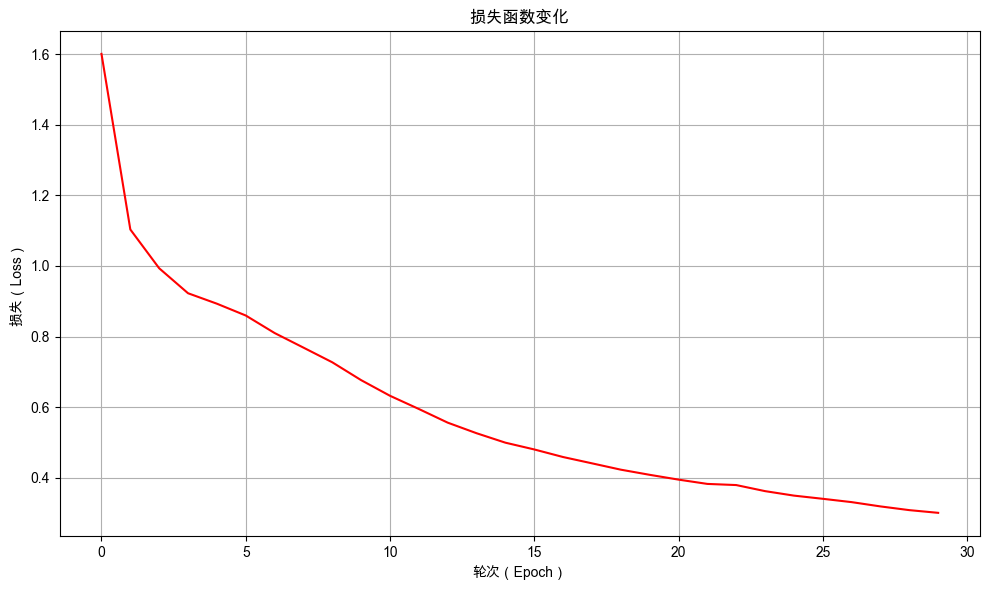

In [62]:
from util import plot_training_loss

plot_training_loss(model.train_epoch_losses)

从训练日志中可以看出随着训练的进行，损失值不断下降，表示模型预测准确性不断提高。

#### 查看模型评估记录

查看训练过程中的评估结果，更直观地观察模型在验证集上的表现。

In [63]:
from util import show_table

show_table(model.eval_accuracies)

,epoch,总样本数,正确样本数,准确率
0,0,30,10,0.3333
1,2,30,10,0.3333
2,5,30,25,0.8333
3,8,30,22,0.7333
4,11,30,29,0.9667
5,14,30,28,0.9333
6,17,30,30,1.0000
7,20,30,30,1.0000
8,23,30,29,0.9667
9,26,30,30,1.0000


## 训练后评估

In [64]:
# 直接调用验证函数进行训练前评估
trainer.validate(model=model, datamodule=coffee_datamodule)

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │           30.0            │
│       total_samples       │           30.0            │
│      val_overall_acc      │            1.0            │
└───────────────────────────┴───────────────────────────┘

[{'total_samples': 30.0, 'total_correct': 30.0, 'val_overall_acc': 1.0}]

从评估结果中可以看出，训练前的模型的准确率是33.3%，训练后的准确率是100%，说明模型训练非常有效果。

## 使用模型进行预测

In [66]:
from util import print_classification_results

# 初始化各类别的标签到ID的映射关系（需要和训练模型时一致）
label_to_id = {"生椰拿铁": 0, "双椰拿铁": 1, "烤椰拿铁": 2}
id_to_label = {v: k for k, v in label_to_id.items()}

# 1️⃣ 假设我们有几个新的咖啡样本，每个样本包含[椰浆, 咖啡, 牛奶, 糖]四个特征
new_samples = [[4.4, 2.9, 1.4, 0.2], [6, 2.9, 4.5, 1.5], [6.9, 3.2, 5.7, 2.3]]
# 定义这些样本对应的真实标签
true_labels = ["生椰拿铁", "双椰拿铁", "烤椰拿铁"]
# 将真实标签转换为对应的ID
true_label_ids = [label_to_id[label] for label in true_labels]

# 2️⃣ 设置模型标签映射关系
model.setup_label_map(id_to_label)

# 3️⃣ 使用训练好的模型对每个样本进行预测
predictions, decoded_predictions, probabilities = model.predict(new_samples)

# 4️⃣ 输出最终的分类预测结果，包括准确率统计和详细对比
print_classification_results(new_samples, true_label_ids, predictions, probabilities, dataset.id_to_label)


🎯 分类预测结果 (准确率: 3/3 = 100.00%)：
+----------------------+----------+----------+----------+------+
|         输入         | 真实标签 | 预测标签 | 最高概率 | 标记 |
+----------------------+----------+----------+----------+------+
| [4.4, 2.9, 1.4, 0.2] | 生椰拿铁 | 生椰拿铁 |  0.9351  |  ☑   |
|  [6, 2.9, 4.5, 1.5]  | 双椰拿铁 | 双椰拿铁 |  0.5849  |  ☑   |
| [6.9, 3.2, 5.7, 2.3] | 烤椰拿铁 | 烤椰拿铁 |  0.7382  |  ☑   |
+----------------------+----------+----------+----------+------+


从结果中我们可以看到，模型在所有测试样本上都做出了正确预测。但是，对每一个样本模型的置信度仍然存在差异，尤其是样本2的预测概率相对较低，说明模型对这个样本的分类相对不够确定，表示模型对预测的结果不够自信。

## 本章小结

本章我们使用PyTorch Lightning成功重构了项目。通过将数据管理封装进`LightningDataModule`、模型逻辑封装进`LightningModule`，并交由统一的`Trainer`驱动训练，我们实现了代码的职责分离。这大幅减少了样板代码，标志着我们的代码从“实验原型”进化到了“可维护、可扩展”的工程系统。

:::{admonition} 本章所学内容 
:class: note
- PyTorch Lightning 通过 LightningModule 和 LightningDataModule 将模型、数据、训练逻辑解耦，极大提升了代码的模块化和可维护性。
- PyTorch Lightning通过 LightningDataModule 将数据加载、分割与准备的生命周期进行模块化管理。
- LightningModule 通过 `training_step`, `validation_step`, `configure_optimizers` 等接口标准化了训练流程。
- 使用`Trainer`类自动化管理整个训练流程，无需手动编写训练循环，使开发者能更专注于模型本身。
- 使用更高阶的训练工具进行重构使得代码更清晰，实现了数据、模型与训练逻辑的职责分离，减少了样板代码。
- PyTorch Lightning 框架提供了内置的日志记录、检查点保存和指标跟踪功能，简化了训练状态管理。
:::